📅 **论文年份 (Year):2020 年(arXiv)/ ICLR 2021**
*An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale (ViT) — Dosovitskiy et al., Google Research*

# Bonus Paper 32: Vision Transformer(一张图等于 16×16 个词)
## Dosovitskiy et al., Google Research(多索维茨基等)

### Implementation: Mini-ViT from Scratch with Manual Backpropagation(实现:纯 NumPy 手写反向传播的迷你 ViT)

This notebook builds a complete Vision Transformer in pure NumPy — patchify, patch embedding, [CLS] token, learnable position embeddings, multi-head self-attention encoder — and trains it with **fully hand-derived backpropagation** (through softmax attention, residual connections, and RMS normalization) on a synthetic colored-shape classification task. We then visualize what the trained model attends to.

本笔记本只用 NumPy 从零构建一个完整的 Vision Transformer:图像切块(patchify)、patch 嵌入、[CLS] token、可学习位置编码、多头自注意力编码器,并用**完全手写推导的反向传播**(梯度穿过 softmax 注意力、残差连接和 RMS 归一化)在合成彩色几何图形分类任务上训练收敛,最后可视化模型"看哪里"。

> 注:ViT 不在 Sutskever 原始 30 篇书单中,是本仓库的多模态扩展(Bonus)。它与 Paper 13(Transformer)的最大差异点:Paper 13 只做了前向实现,本篇把注意力的**反向传播**也完整手写出来;它也是 Bonus Paper 31(CLIP)图像塔的真实架构。

## 📖 论文导读

**🎯 这篇文章想解决什么问题(目的):** 2020 年之前,计算机视觉被卷积网络(CNN)统治了近十年——AlexNet、ResNet 的成功让"图像必须用卷积处理"几乎成为公理。而 NLP 领域早已被 Transformer 接管。ViT 想回答一个大胆的问题:能不能**完全抛弃卷积**,把一张图像直接当成"一句话"喂给标准 Transformer?卷积自带的局部性、平移等变性这些归纳偏置(inductive bias),究竟是必需品还是可以用数据买回来的拐杖?

**💡 主要贡献:** ViT 证明了:(1) 把图像切成 16×16 的 patch、每个 patch 线性投影成一个"词向量"后,一个**几乎不加修改的标准 Transformer 编码器**就能做图像分类;(2) 在中等规模数据(ImageNet-1k)上 ViT 不如同级 CNN——因为它缺少卷积的归纳偏置;但在超大规模数据(JFT-300M,3 亿张图)上预训练后,ViT 反超最强的 CNN,且训练计算量更少;(3) 归纳偏置的价值随数据量增长而递减——**大数据可以买回先验**。

**🔧 方法:** 图像 (H,W,3) 切成不重叠的 P×P patch,每个 patch 展平后线性投影到 d 维,得到"patch 词序列";前面拼接一个可学习的 [CLS] token(继承自 BERT),加上可学习的位置编码;送入标准 Transformer 编码器(多头自注意力 + MLP,pre-norm 残差结构);最后取 [CLS] 位置的输出向量接线性分类头。本笔记本在 16×16×3 的合成图像上完整复现这条流水线(4×4 patch → 16 个 patch),2 层编码器、4 头注意力,共 4.1 万参数,全部梯度手工推导。

**🌟 意义:** ViT 统一了视觉与语言的架构——从此"万物皆 token"。它是 CLIP(Bonus 31)的图像编码器、是 MAE/DINO 等自监督视觉方法的骨干、是 GPT-4V/LLaVA 等多模态大模型的视觉前端;它提出的"数据规模 vs 归纳偏置"的权衡也成为大模型时代的核心设计哲学:当数据足够多,通用架构 + 大规模训练胜过手工设计的先验。

## 🎯 核心结论 (Key Takeaways)

- **图像真的可以当句子处理。** 16×16 图像切成 16 个 4×4 patch(一次 reshape+transpose,零循环),经 2 层、4.1 万参数的纯 NumPy Transformer,9 类彩色形状分类达到 **93.5% 测试准确率**(随机水平 11.1%)——全程没有一个卷积核。

- **手写反向传播完全可行且可验证。** 梯度穿过 softmax 注意力(dS = A⊙(dA − Σ(dA⊙A)))、残差连接(两条支路梯度相加)、RMS 归一化(投影掉沿自身方向的分量)后,与数值梯度的相对误差最大仅 **5.6e-5**(< 1e-4)——链式法则不会说谎。

- **[CLS] 注意力就是模型的"视线"。** 训练后 [CLS] 对 16 个 patch 的注意力从近乎均匀(最大权重 0.10,完全均匀为 1/16≈0.06)变为高度聚焦(最大权重 **0.33**),与"该 patch 中有多少形状像素"的相关系数达 **0.79**——模型自己学会了把视线聚焦在物体上,没有任何定位监督。

- **位置编码学到的是"哪里有内容"。** 16 个位置编码的余弦相似度显示:中心 4 个 patch(形状出现区)彼此相似度 0.100,约为中心-边缘(0.020)的 5 倍——位置编码把"内容区"和"背景区"区分开了。但这种结构很微弱,ViT 论文 Fig 10 那种精细 2D 网格结构没有出现:那需要海量数据与位置敏感的任务。

- **这个任务几乎不需要位置——ViT 近似一个集合处理器。** 推理时把位置编码清零,准确率仅从 93.5% 降到 91.8%;把 16 个 patch 随机打乱,也还有 90.2%。除位置编码外,自注意力对 patch 顺序完全无感(对比 Paper 8 的集合处理思想)。

- **ViT 需要大数据不是玄学,小实验就能看见。** 100 个训练样本时,4.1 万参数的 ViT(42.4%)**输给** 7 千参数的逻辑回归(48.0%);1600 个样本时 ViT(91.1%)反超 26 个百分点(逻辑回归 65.1%)——3 个随机种子取均值,这正是 ViT 论文"归纳偏置 vs 数据规模"结论的微缩版。

## 🤯 反常识的发现 (Counterintuitive Findings)

- **常识认为:图像是 2D 网格,必须用卷积的滑动窗口处理。** ViT 把图像切块后当成**无序 token 集合 + 位置编码**交给标准 Transformer,分类照样 93.5%。卷积十年积累的"局部性、平移等变性"先验,在 Transformer 里被压缩成了一行可学习的位置编码。

- **常识认为:去掉位置编码,Transformer 就"瞎"了。** 本实验把训练好的模型的位置编码清零,准确率只从 93.5% 掉到 91.8%(不到 2 个百分点);连 patch 顺序打乱都还有 90.2%。原因:颜色是逐像素属性,形状也能从"patch 内容的袋子"(弧形边/直边/斜边)大致推断——这个任务**近似置换不变**。ViT 论文其实有同样的观察:1D、2D、相对位置编码效果几乎一样,位置信息远没想象中重要。

- **常识认为:模型越强,数据少时也应该越好。** n=100 时,ViT 训练准确率 100%(完美记忆)但测试只有 42.4%,被最简单的逻辑回归(48.0%)反超——没有归纳偏置的高容量模型在小数据上先学会的是**背题**。数据到 1600 时形势彻底逆转(91.1% vs 65.1%)。这就是 ViT 论文用 3 亿张图才"喂饱"Transformer 的原因。

- **常识认为:注意力权重是难以解读的黑盒中间量。** 恰恰相反,[CLS] 的注意力分布是 ViT 最透明的窗口:不加任何定位标签训练,它的注意力从近乎均匀(最大权重 0.10)变为聚焦在物体 patch 上(0.33,与形状位置相关系数 0.79)——**分类监督免费送了一个粗糙的物体检测器**。有趣的是,即使随机初始化的模型,注意力也与内容弱相关(0.52):patch 内容会通过嵌入范数"泄漏"进注意力分数——但那时的注意力幅度平坦得毫无用处。

#### 💻 代码解读

**做什么:** 导入依赖并固定随机种子,保证实验可复现。

**怎么做:**
- 只用 `numpy`(数值计算)和 `matplotlib`(画图),与本仓库其他 notebook 保持一致——不依赖任何深度学习框架,反向传播全部手写。
- `deepcopy` 用于在训练前快照一份"未训练"的模型参数,后面做训练前/后注意力对比图。
- 固定两个随机源:全局 `np.random.seed` 和新式 `default_rng`;数据生成、参数初始化、批次采样都走 `rng`,结果完全可复现。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

np.random.seed(42)
# 新式随机数生成器:数据生成、参数初始化、采样都用它,保证可复现
rng = np.random.default_rng(0)

## Synthetic Dataset: Colored Shapes(合成数据集:彩色几何图形)

#### 💻 代码解读

**做什么:** 生成 16×16×3 的彩色几何图形图像:3 种颜色 × 3 种形状 = 9 个类别,带位置/大小抖动和噪声(与 Bonus 31 同款生成器)。

**怎么做:**
- `draw_image`:用 `np.mgrid` 一次生成全部像素坐标,再用布尔掩码向量化"画图"——圆是距离方程、方形是切比雪夫距离、三角形是三个半平面的交集,全程无循环。
- 位置抖动(圆心在 5.5~10.5 之间)和大小抖动(半径 3~5)迫使模型学"概念"而非死记像素位置——这对后面检验位置编码的作用至关重要。
- `make_dataset` 均匀采样 9 个类别,标签为 0~8 的整数。
- 训练集 1800 张、测试集 400 张,最后展示 9 类样例。

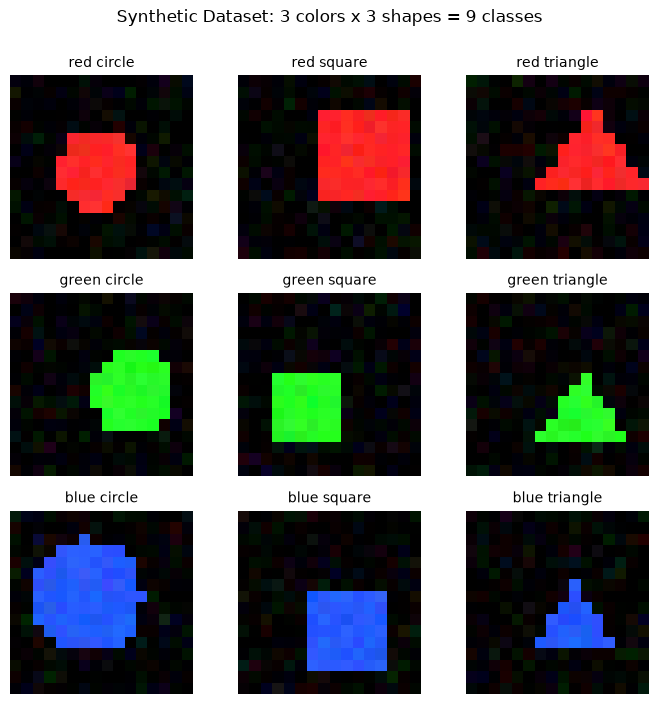

Train: (1800, 16, 16, 3), Test: (400, 16, 16, 3), classes: 9


In [2]:
# 3种颜色 x 3种形状 = 9个类别
COLORS = {'red': (1.0, 0.15, 0.15), 'green': (0.15, 1.0, 0.15), 'blue': (0.15, 0.35, 1.0)}
SHAPES = ['circle', 'square', 'triangle']
ALL_PAIRS = [(c, s) for c in COLORS for s in SHAPES]
IMG = 16  # 图像尺寸 16x16x3

def draw_image(color, shape, rng):
    """Draw one colored shape with position/size jitter and noise"""
    img = np.zeros((IMG, IMG, 3))
    img += rng.normal(0, 0.04, img.shape)  # 背景噪声
    # 位置和大小随机抖动:迫使模型学"概念"而不是死记像素位置
    cx, cy = rng.uniform(5.5, 10.5, 2)
    r = rng.uniform(3.0, 5.0)
    # np.mgrid一次生成所有像素的(行,列)坐标网格,形状均为(16,16)
    yy, xx = np.mgrid[0:IMG, 0:IMG]
    if shape == 'circle':
        # 布尔掩码:到圆心距离平方<=r^2的像素为True,向量化代替双重循环
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
    elif shape == 'square':
        mask = (np.abs(xx - cx) <= r * 0.8) & (np.abs(yy - cy) <= r * 0.8)
    else:  # triangle
        # 三角形=三条边的半平面交集:顶点在上,宽度随y线性增大
        mask = ((yy - (cy - r) >= 0) & (yy - (cy - r) <= 1.5 * r)
                & (np.abs(xx - cx) <= (yy - (cy - r)) / 1.5))
    # 花式索引:mask为True的所有像素一次性赋成该颜色
    img[mask] = COLORS[color]
    img += rng.normal(0, 0.03, img.shape)
    return np.clip(img, 0, 1)

def make_dataset(n, rng):
    """Generate n labeled images, classes drawn uniformly from the 9 pairs"""
    X, y = [], []
    for _ in range(n):
        k = rng.integers(9)
        c, s = ALL_PAIRS[k]
        X.append(draw_image(c, s, rng))
        y.append(k)
    return np.array(X), np.array(y)

# 可视化9个类别各一个样本
fig, axes = plt.subplots(3, 3, figsize=(7, 7))
for ax, (c, s) in zip(axes.flat, ALL_PAIRS):
    ax.imshow(draw_image(c, s, rng))
    ax.set_title(f'{c} {s}', fontsize=10)
    ax.axis('off')
plt.suptitle('Synthetic Dataset: 3 colors x 3 shapes = 9 classes', y=1.0)
plt.tight_layout()
plt.show()

Xtr, ytr = make_dataset(1800, rng)
Xte, yte = make_dataset(400, rng)
print(f'Train: {Xtr.shape}, Test: {Xte.shape}, classes: {len(ALL_PAIRS)}')

## Patchify: An Image Becomes 16 "Words"(切块:一张图变成 16 个"词")

#### 💻 代码解读

**做什么:** 把 (N,16,16,3) 的图像批量切成 (N,16,48) 的 patch 序列——每张图 16 个 4×4 patch,每个 patch 展平成 48 维向量。**零循环**,这是 ViT 落地 NumPy 的第一个关键技巧。

**怎么做:**
- 核心是一行 `reshape + transpose`:
  1. `reshape(N, 4, 4, 4, 4, 3)` 把高度 16 拆成 (4 个 patch 行 × 每 patch 4 像素),宽度同理——此时轴的含义是 (batch, patch行, 像素行, patch列, 像素列, 通道);
  2. `transpose(0,1,3,2,4,5)` 把两个 "patch 网格轴" 换到前面、两个 "patch 内像素轴" 换到后面——这一步只改变内存视图的步幅(stride),不复制数据;
  3. 最后 `reshape(N, 16, 48)` 把 (patch行,patch列) 合并成 16 个 patch、(像素行,像素列,通道) 合并成 48 维向量。
- 用显式双重循环的朴素实现交叉验证,`np.allclose` 确认两者完全一致——学 reshape 技巧时一定要这样自检,轴顺序错了结果照样有形状、只是内容悄悄错乱。
- 图中把一张图与它的 16 个 patch 并排画出,patch 编号按行优先(row-major)排列,与位置编码的下标一一对应。

patchify (reshape+transpose) == naive loops: verified


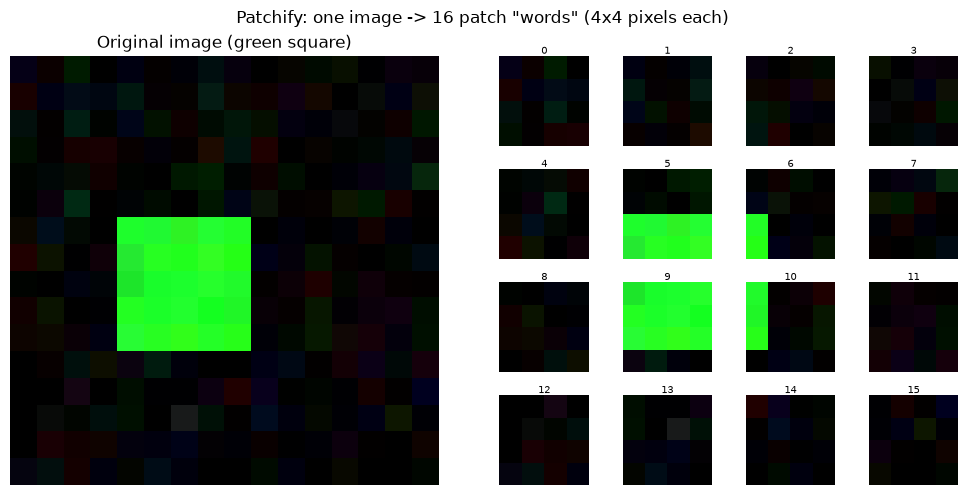

In [3]:
P = 4                  # patch大小 4x4
NP_SIDE = IMG // P     # 每边4个patch
N_PATCH = NP_SIDE ** 2 # 共16个patch
D_PATCH = P * P * 3    # 每个patch展平后48维

def patchify(x):
    """(N,16,16,3) -> (N,16,48): cut into 4x4 patches via reshape+transpose"""
    N = x.shape[0]
    # 步骤1: 高16拆成(4个patch行 x 4像素), 宽同理 -> (N,4,4,4,4,3)
    #        轴含义: (batch, patch行, 像素行, patch列, 像素列, 通道)
    p = x.reshape(N, NP_SIDE, P, NP_SIDE, P, 3)
    # 步骤2: 把两个patch网格轴换到前面 -> (batch, patch行, patch列, 像素行, 像素列, 通道)
    #        transpose只改变stride视图,不复制数据
    p = p.transpose(0, 1, 3, 2, 4, 5)
    # 步骤3: 合并(patch行,patch列)->16个patch, 合并(像素行,像素列,通道)->48维
    return p.reshape(N, N_PATCH, D_PATCH)

# 用朴素双重循环交叉验证reshape技巧的正确性
def patchify_naive(x):
    """Reference implementation with explicit loops"""
    N = x.shape[0]
    out = np.zeros((N, N_PATCH, D_PATCH))
    for i in range(NP_SIDE):
        for j in range(NP_SIDE):
            # 第(i,j)个patch = 像素块[4i:4i+4, 4j:4j+4],行优先编号i*4+j
            out[:, i * NP_SIDE + j] = x[:, i*P:(i+1)*P, j*P:(j+1)*P, :].reshape(N, -1)
    return out

assert np.allclose(patchify(Xte[:8]), patchify_naive(Xte[:8]))
print('patchify (reshape+transpose) == naive loops: verified')

# 可视化:一张图 -> 16个patch
demo = Xtr[0]
patches = patchify(demo[None])[0]  # (16,48)
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 2, 1)
ax.imshow(demo)
ax.set_title(f'Original image ({ALL_PAIRS[ytr[0]][0]} {ALL_PAIRS[ytr[0]][1]})')
ax.axis('off')
for k in range(N_PATCH):
    r, c = divmod(k, NP_SIDE)
    ax2 = fig.add_subplot(4, 8, (r * 8) + 5 + c)
    ax2.imshow(patches[k].reshape(P, P, 3))
    ax2.set_title(f'{k}', fontsize=7, pad=1)
    ax2.axis('off')
plt.suptitle('Patchify: one image -> 16 patch "words" (4x4 pixels each)')
plt.tight_layout()
plt.show()

## Mini-ViT Architecture(迷你 ViT 架构与参数初始化)

#### 💻 代码解读

**做什么:** 定义并初始化迷你 ViT 的全部参数:patch 嵌入、[CLS] token、可学习位置编码、2 层 Transformer 编码器(4 头注意力 + MLP)、分类头,共约 4.1 万参数。

**怎么做:**
- 结构与 ViT 论文逐项对应:`We/be` 是 patch 的线性投影(论文 Eq.1 的 E);`cls` 是可学习 [CLS] token(继承 BERT,分类只读它的最终状态);`pos` 是 17×48 的**可学习**位置编码(ViT 用学习式而非 Paper 13 的正弦式,17 = CLS + 16 patch)。
- 每层参数:`g1/g2` 是两处 RMSNorm 的增益;`Wq/Wk/Wv/Wo` 是注意力的四个投影;`W1/b1/W2/b2` 是 MLP(48→96→48,ReLU)。
- 初始化:线性层用 He/Xavier 风格的 `sqrt(k/fan_in)` 高斯;`cls/pos` 用小方差 0.02 高斯(嵌入类参数的惯例);归一化增益初始化为 1。
- 所有参数放进一个扁平 dict(键如 `'0Wq'` 表示第 0 层的 Wq),训练时可以统一遍历做 Adam 更新。

In [4]:
D = 48      # 模型宽度d_model(恰好等于patch维度48,纯属方便,二者无必然联系)
H = 4       # 注意力头数
DH = D // H # 每头维度12
HID = 96    # MLP隐层宽度(ViT惯例为4x,这里用2x保持轻量)
L = 2       # 编码器层数
T = N_PATCH + 1  # token数 = [CLS] + 16个patch = 17
N_CLASS = 9
EPS = 1e-6

def init_params(rng):
    """Initialize all mini-ViT parameters in one flat dict"""
    p = {}
    # patch嵌入: 48维patch向量线性投影到D维(ViT论文Eq.1的E)
    p['We'] = rng.normal(0, np.sqrt(2 / D_PATCH), (D_PATCH, D))
    p['be'] = np.zeros(D)
    # 可学习[CLS] token(继承自BERT)与可学习位置编码(17个位置)
    p['cls'] = rng.normal(0, 0.02, D)
    p['pos'] = rng.normal(0, 0.02, (T, D))
    for l in range(L):
        p[f'{l}g1'] = np.ones(D)   # 注意力前RMSNorm的增益
        for nm in ['Wq', 'Wk', 'Wv', 'Wo']:
            p[f'{l}{nm}'] = rng.normal(0, np.sqrt(1 / D), (D, D))
        p[f'{l}g2'] = np.ones(D)   # MLP前RMSNorm的增益
        p[f'{l}W1'] = rng.normal(0, np.sqrt(2 / D), (D, HID))
        p[f'{l}b1'] = np.zeros(HID)
        p[f'{l}W2'] = rng.normal(0, np.sqrt(2 / HID), (HID, D))
        p[f'{l}b2'] = np.zeros(D)
    p['gf'] = np.ones(D)  # 分类头前的最终RMSNorm
    p['Wh'] = rng.normal(0, np.sqrt(1 / D), (D, N_CLASS))
    p['bh'] = np.zeros(N_CLASS)
    return p

params = init_params(rng)
n_params = sum(v.size for v in params.values())
print(f'mini-ViT: {L} layers, {H} heads, d_model={D}, {n_params:,} parameters')

mini-ViT: 2 layers, 4 heads, d_model=48, 41,049 parameters


## Forward Pass: Pre-Norm Transformer Encoder(前向传播:pre-norm Transformer 编码器)

#### 💻 代码解读

**做什么:** 实现完整前向传播:patch 嵌入 + [CLS] + 位置编码 → 2 层(RMSNorm → 多头自注意力 → 残差 → RMSNorm → MLP → 残差)→ 最终 RMSNorm → 分类头。每一步的中间量都存入 cache,供反向传播使用。

**怎么做:**
- **RMSNorm 代替 LayerNorm**:原版 ViT 用 LayerNorm(减均值、除标准差、γ/β 仿射);这里用 RMSNorm(只除以均方根、乘增益 g)——去掉减均值和 β 后反向传播明显更简洁,而效果在实践中几乎等价(LLaMA/T5 均采用 RMSNorm)。这是本实现与原论文最主要的架构差异;另有几处小偏离一并注明:MLP 激活用 ReLU(原版为 GELU)、QKV 投影不带偏置(原版带)、未使用 dropout——均不影响本玩具实验的结论。
- **pre-norm 结构**:归一化放在残差支路内部(`x + Attn(Norm(x))`),与 ViT 论文一致(Paper 15 讲过的"干净残差通路"思想:主通路上没有任何变换,梯度可以无衰减直达底层)。
- **多头注意力**:`split_heads` 把 (N,T,D) 重排成 (N,H,T,DH);NumPy 的 `@` 自动对前两个 batch 维广播,`Q@K^T/sqrt(DH)` 一次算出全部 (N,H,T,T) 注意力分数;softmax 前减每行最大值防上溢。
- [CLS] 是第 0 个 token;它与 16 个 patch 一起参与每层注意力,最后只取它的输出向量做分类——它是模型自己学出来的"全图摘要槽"。

In [5]:
def rms_fwd(x, g):
    """RMSNorm: y = x / rms(x) * g  (no mean subtraction, cf. LayerNorm in the paper)"""
    # 沿最后一维求均方根;+EPS防除零。与LayerNorm的差异:不减均值、无beta偏置
    r = np.sqrt((x ** 2).mean(-1, keepdims=True) + EPS)
    return x / r * g, (x, r)   # cache(x,r)供反向传播

def softmax(z):
    # 数值稳定:先减最后一维的最大值再exp,结果不变但不会上溢
    z = z - z.max(-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(-1, keepdims=True)

def split_heads(z):
    """(N,T,D) -> (N,H,T,DH): reshape then swap the head axis forward"""
    return z.reshape(z.shape[0], T, H, DH).transpose(0, 2, 1, 3)

def merge_heads(z):
    """(N,H,T,DH) -> (N,T,D): inverse of split_heads"""
    return z.transpose(0, 2, 1, 3).reshape(z.shape[0], T, D)

def forward_tokens(p, xp):
    """Forward pass from patch vectors (N,16,48); returns logits, attentions, cache"""
    cache = {'xp': xp}
    N = xp.shape[0]
    emb = xp @ p['We'] + p['be']                       # patch嵌入 (N,16,D)
    # 前置[CLS] token(broadcast到整个batch),再加可学习位置编码
    x = np.concatenate([np.broadcast_to(p['cls'], (N, 1, D)), emb], axis=1) + p['pos']
    attns = []
    for l in range(L):
        c = {'x_in': x}
        # ---- 注意力子层: x = x + Wo·MultiHead(RMSNorm(x)) ----
        xn, c['n1'] = rms_fwd(x, p[f'{l}g1'])
        c['xn'] = xn
        q = split_heads(xn @ p[f'{l}Wq'])              # (N,H,17,12)
        k = split_heads(xn @ p[f'{l}Wk'])
        v = split_heads(xn @ p[f'{l}Wv'])
        # 缩放点积注意力:@对(N,H)两个batch维自动广播 -> (N,H,17,17)
        A = softmax(q @ k.transpose(0, 1, 3, 2) / np.sqrt(DH))
        mh = merge_heads(A @ v)                        # 各头拼接回(N,17,D)
        x = x + mh @ p[f'{l}Wo']                       # 残差连接
        c.update(q=q, k=k, v=v, A=A, mh=mh, x_mid=x)
        # ---- MLP子层: x = x + W2·ReLU(W1·RMSNorm(x)) ----
        hn, c['n2'] = rms_fwd(x, p[f'{l}g2'])
        c['hn'] = hn
        h1 = hn @ p[f'{l}W1'] + p[f'{l}b1']
        hr = np.maximum(h1, 0)
        x = x + hr @ p[f'{l}W2'] + p[f'{l}b2']
        c.update(h1=h1, hr=hr)
        cache[l] = c
        attns.append(A)
    # 只取[CLS](第0个token)的最终状态,过最终RMSNorm后接分类头
    cn, cache['nf'] = rms_fwd(x[:, 0], p['gf'])
    cache['cn'] = cn
    cache['x_last'] = x
    return cn @ p['Wh'] + p['bh'], attns, cache

def forward(p, imgs):
    """Convenience wrapper: images -> logits"""
    return forward_tokens(p, patchify(imgs))

logits0, attns0, _ = forward(params, Xte[:5])
print(f'logits shape: {logits0.shape}, attention shape per layer: {attns0[0].shape}')

logits shape: (5, 9), attention shape per layer: (5, 4, 17, 17)


## Manual Backpropagation(手写反向传播:梯度如何流过注意力)

#### 💻 代码解读

**做什么:** 从交叉熵损失出发,手工把梯度反向传过分类头、最终归一化、两层编码器(MLP 子层 + 注意力子层)直到 patch 嵌入和位置编码,得到全部参数的解析梯度。这是本篇与 Paper 13(仅前向)的最大差异点。

**怎么做(梯度怎么流):**
- **softmax + 交叉熵**:合并后梯度是著名的 `probs - onehot`(除以 batch 大小)。
- **残差连接**:前向 `x_out = x + f(x)` 意味着反向 `dx = dx_out + df分支回传的梯度`——梯度沿主通路**原样直达**,这就是残差让深网络可训练的代数原因(Paper 10/15)。代码里体现为多处 `dx = dx + ...`。
- **RMSNorm**(`rms_bwd`):对 y = g·x/r,r=rms(x),雅可比要求把梯度中"沿 x 自身方向"的分量按比例扣掉:`dx = u/r − x·Σ(u⊙x)/(d·r³)`(u=g⊙dy)。直觉:x 等比放大不改变输出,所以径向分量的梯度必须被消去。
- **softmax 注意力**(最关键的一步):对每行注意力分布 A,`dS = A ⊙ (dA − Σ(dA⊙A))`——即"先中心化再按概率加权";随后 `dQ = dS@K/√dh`、`dK = dSᵀ@Q/√dh`、`dV = Aᵀ@dAV`。注意 K 的梯度要转置 dS:因为 S=QKᵀ 中 K 出现在转置位置。
- **[CLS] 的梯度入口**:损失只连着 x_last 的第 0 个 token,所以反向起点是一个几乎全零的张量,仅第 0 行有梯度——之后注意力会把它"扩散"到所有 patch(正如前向时 [CLS] 从所有 patch 收集信息)。
- 位置编码的梯度 = 各 token 梯度对 batch 求和;[CLS] 的梯度再单独累加第 0 个 token;`We` 的梯度来自全部 patch token。最后附标准 Adam(带偏差修正)。

In [6]:
def rms_bwd(dy, cache, g):
    """Backprop through RMSNorm; returns dx and dgain"""
    x, r = cache
    # 增益g的梯度:对除最后一维外的所有维度求和
    dg = (dy * x / r).sum(tuple(range(x.ndim - 1)))
    u = dy * g
    # 核心:扣除沿x自身方向的径向分量(x等比缩放不改变输出,该方向导数为0)
    dx = u / r - x * (u * x).sum(-1, keepdims=True) / (x.shape[-1] * r ** 3)
    return dx, dg

def loss_and_grads(p, imgs, y):
    """Forward + full manual backward; returns loss, accuracy, grads, attentions"""
    logits, attns, cache = forward(p, imgs)
    N = imgs.shape[0]
    probs = softmax(logits)
    loss = -np.log(probs[np.arange(N), y] + 1e-12).mean()
    acc = (logits.argmax(1) == y).mean()
    g = {k: np.zeros_like(v) for k, v in p.items()}

    # softmax+交叉熵的合并梯度:probs - onehot,再除以batch大小
    dlogits = probs.copy()
    dlogits[np.arange(N), y] -= 1
    dlogits /= N
    g['Wh'] = cache['cn'].T @ dlogits
    g['bh'] = dlogits.sum(0)
    dcn = dlogits @ p['Wh'].T
    dclsf, g['gf'] = rms_bwd(dcn, cache['nf'], p['gf'])
    # 梯度入口:损失只连着[CLS](第0个token),其余token起点梯度为0
    dx = np.zeros_like(cache['x_last'])
    dx[:, 0] = dclsf

    for l in reversed(range(L)):
        c = cache[l]
        # ---- MLP子层反向: x = x_mid + ReLU(hn@W1+b1)@W2+b2 ----
        g[f'{l}W2'] = c['hr'].reshape(-1, HID).T @ dx.reshape(-1, D)
        g[f'{l}b2'] = dx.sum((0, 1))
        dh1 = (dx @ p[f'{l}W2'].T) * (c['h1'] > 0)   # ReLU: 正区通过,负区截断
        g[f'{l}W1'] = c['hn'].reshape(-1, D).T @ dh1.reshape(-1, HID)
        g[f'{l}b1'] = dh1.sum((0, 1))
        dxm, g[f'{l}g2'] = rms_bwd(dh1 @ p[f'{l}W1'].T, c['n2'], p[f'{l}g2'])
        # 残差:主通路梯度dx与支路梯度dxm相加(梯度沿捷径无衰减直达)
        dx = dx + dxm

        # ---- 注意力子层反向: x_mid = x_in + merge(A@V)@Wo ----
        g[f'{l}Wo'] = c['mh'].reshape(-1, D).T @ dx.reshape(-1, D)
        dav = split_heads(dx @ p[f'{l}Wo'].T)         # d(A@V), (N,H,17,12)
        dA = dav @ c['v'].transpose(0, 1, 3, 2)       # (N,H,17,17)
        dv = c['A'].transpose(0, 1, 3, 2) @ dav
        # softmax反向(逐行): dS = A*(dA - sum(dA*A)),即"中心化再按概率加权"
        dS = c['A'] * (dA - (dA * c['A']).sum(-1, keepdims=True))
        # S = Q@K^T/sqrt(dh):K在转置位置,故dK用dS的转置
        dq = dS @ c['k'] / np.sqrt(DH)
        dk = dS.transpose(0, 1, 3, 2) @ c['q'] / np.sqrt(DH)
        dq_m, dk_m, dv_m = merge_heads(dq), merge_heads(dk), merge_heads(dv)
        xn2 = c['xn'].reshape(-1, D)
        g[f'{l}Wq'] = xn2.T @ dq_m.reshape(-1, D)
        g[f'{l}Wk'] = xn2.T @ dk_m.reshape(-1, D)
        g[f'{l}Wv'] = xn2.T @ dv_m.reshape(-1, D)
        # 三个投影共享同一个输入xn:梯度相加后一起穿过RMSNorm
        dxn = dq_m @ p[f'{l}Wq'].T + dk_m @ p[f'{l}Wk'].T + dv_m @ p[f'{l}Wv'].T
        dxi, g[f'{l}g1'] = rms_bwd(dxn, c['n1'], p[f'{l}g1'])
        dx = dx + dxi                                  # 又一处残差梯度汇合

    # 位置编码梯度=各token梯度对batch求和;[CLS]梯度取第0个token
    g['pos'] = dx.sum(0)
    g['cls'] = dx[:, 0].sum(0)
    demb = dx[:, 1:]                                   # 16个patch token的梯度
    g['We'] = cache['xp'].reshape(-1, D_PATCH).T @ demb.reshape(-1, D)
    g['be'] = demb.sum((0, 1))
    return loss, acc, g, attns

def adam_update(p, g, m, v, t, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    for k in p:
        m[k] = b1 * m[k] + (1 - b1) * g[k]
        v[k] = b2 * v[k] + (1 - b2) * g[k] ** 2
        # 偏差修正:除以(1-beta^t),抵消动量初始化为0造成的低估
        p[k] -= lr * (m[k] / (1 - b1 ** t)) / (np.sqrt(v[k] / (1 - b2 ** t)) + eps)

print('Manual backprop and Adam ready.')

Manual backprop and Adam ready.


#### 💻 代码解读

**做什么:** 用中心差分数值梯度校验手写反向传播——这是手写 backprop 的**必做仪式**,任何一处链式法则出错都会在这里现形。

**怎么做:**
- 抽查 8 个代表性参数(patch 嵌入、位置编码、CLS、注意力 Wq、两处归一化增益、MLP W2、分类头),每个随机选一个标量分量;
- 数值梯度 = (L(θ+ε) − L(θ−ε)) / 2ε,ε=1e-5(中心差分误差是 O(ε²),比单侧差分精确得多);
- 相对误差 = |数值−解析| / (|数值|+|解析|),小于 1e-4 即通过(浮点舍入决定了不可能到 0)。

In [7]:
def grad_check():
    """Compare analytic grads against central finite differences"""
    rng2 = np.random.default_rng(1)   # 独立随机源,不干扰主实验的rng
    p = init_params(rng2)
    X, y = make_dataset(4, rng2)
    _, _, g, _ = loss_and_grads(p, X, y)
    errs = {}
    for k in ['We', 'pos', 'cls', '0Wq', '0g1', '1W2', 'gf', 'Wh']:
        w = p[k]
        idx = tuple(rng2.integers(0, s) for s in w.shape)  # 随机抽一个标量分量
        eps_ = 1e-5
        w[idx] += eps_
        l1, _, _, _ = loss_and_grads(p, X, y)
        w[idx] -= 2 * eps_
        l2, _, _, _ = loss_and_grads(p, X, y)
        w[idx] += eps_                                     # 恢复原值
        num = (l1 - l2) / (2 * eps_)                       # 中心差分,误差O(eps^2)
        ana = g[k][idx]
        errs[k] = abs(num - ana) / (abs(num) + abs(ana) + 1e-12)
    return errs

errs = grad_check()
for k, e in errs.items():
    print(f'  {k:>4s}: relative error = {e:.2e}')
print(f'max relative error = {max(errs.values()):.2e}  (< 1e-4 -> backprop is correct)')

    We: relative error = 1.14e-07
   pos: relative error = 2.76e-10
   cls: relative error = 5.63e-05
   0Wq: relative error = 9.75e-11
   0g1: relative error = 1.73e-10
   1W2: relative error = 8.61e-09
    gf: relative error = 9.18e-10
    Wh: relative error = 7.04e-11
max relative error = 5.63e-05  (< 1e-4 -> backprop is correct)


## Training(训练)

#### 💻 代码解读

**做什么:** 用 Adam 训练迷你 ViT 2500 步(batch=64,约 89 个 epoch),记录损失与测试准确率曲线。

**怎么做:**
- 训练前 `deepcopy` 快照未训练参数,供后面"训练前 vs 训练后"注意力对比。
- 每步随机采 64 张图 → 前向 + 手写反向 → Adam 更新;每 100 步在全部 400 张测试图上评估一次。
- 左图:训练损失(对数轴)从 ln(9)≈2.2(随机猜测)一路降到 1e-4 量级;右图:测试准确率 500 步即越过 90%,而随机水平只有 11.1%。
- 损失降到远低于测试错误率对应的水平 = 模型对训练集近乎完美拟合,泛化 gap 主要来自数据抖动——这为最后的数据效率实验埋下伏笔。

step  500: loss=0.0155  batch_acc=1.00  test_acc=0.910


step 1000: loss=0.0013  batch_acc=1.00  test_acc=0.938


step 1500: loss=0.0005  batch_acc=1.00  test_acc=0.935


step 2000: loss=0.0004  batch_acc=1.00  test_acc=0.935


step 2500: loss=0.0002  batch_acc=1.00  test_acc=0.935
Final test accuracy: 93.5%  (chance = 11.1%)


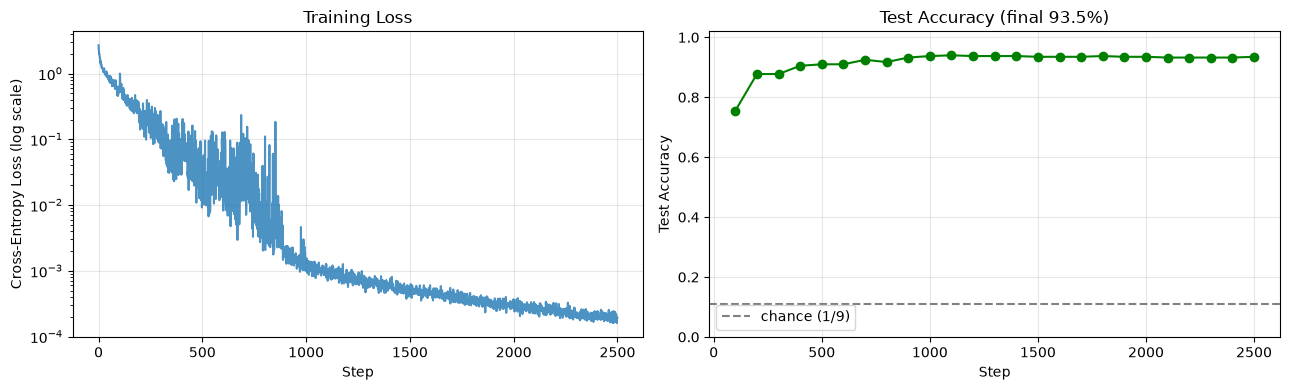

In [8]:
params_untrained = deepcopy(params)   # 快照:训练前的随机参数(对比用)

m = {k: np.zeros_like(v) for k, v in params.items()}
v = {k: np.zeros_like(v_) for k, v_ in params.items()}
B = 64
loss_hist, eval_steps, test_hist = [], [], []

for step in range(1, 2501):
    idx = rng.integers(0, len(Xtr), B)
    loss, acc, g, _ = loss_and_grads(params, Xtr[idx], ytr[idx])
    adam_update(params, g, m, v, step, lr=1.5e-3)
    loss_hist.append(loss)
    if step % 100 == 0:
        lg, _, _ = forward(params, Xte)
        te_acc = (lg.argmax(1) == yte).mean()
        eval_steps.append(step)
        test_hist.append(te_acc)
        if step % 500 == 0:
            print(f'step {step:4d}: loss={loss:.4f}  batch_acc={acc:.2f}  test_acc={te_acc:.3f}')

test_acc = test_hist[-1]
print(f'Final test accuracy: {test_acc:.1%}  (chance = 11.1%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(loss_hist, alpha=0.8)
ax1.set_yscale('log')   # 对数轴:同时看清初期陡降与后期精细收敛
ax1.set_xlabel('Step'); ax1.set_ylabel('Cross-Entropy Loss (log scale)')
ax1.set_title('Training Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(eval_steps, test_hist, marker='o', color='green')
ax2.axhline(1 / 9, color='gray', ls='--', label='chance (1/9)')
ax2.set_xlabel('Step'); ax2.set_ylabel('Test Accuracy')
ax2.set_title(f'Test Accuracy (final {test_acc:.1%})')
ax2.set_ylim(0, 1.02); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Attention Visualization: Where Does [CLS] Look?(注意力可视化:[CLS] 在看哪里)

#### 💻 代码解读

**做什么:** ViT 的招牌可视化——取最后一层 [CLS] 对 16 个 patch 的注意力权重(各头平均),上采样成 16×16 热力图叠加在原图上,对比训练前 vs 训练后。

**怎么做:**
- 注意力张量 A 形状 (N,H,17,17);`A[:, :, 0, 1:]` 取第 0 行([CLS] 作为 query)对 16 个 patch(去掉对自身的注意力)的权重,再对 H 个头求平均。
- `np.kron(att.reshape(4,4), np.ones((4,4)))` 用 Kronecker 积把 4×4 的注意力网格逐块放大成 16×16——每个 patch 的权重铺满它覆盖的 4×4 像素区域。
- 展示样本的挑选标准写在代码里:分类正确且逐图相关系数 ≥0.75(全集均值即 0.79,所以这是"平均水平"的成功案例而非精挑的极端好例);对全部 400 张测试图的诚实汇总指标在本 cell 末尾打印。
- 训练前:注意力近乎均匀(随机初始化的 Q/K 产生的分数彼此接近);训练后:注意力明显聚焦在形状所在的 patch 上。
- 两个定量指标:(1) **聚焦度** = [CLS] 注意力的最大权重(完全均匀时 = 1/16 ≈ 0.062);(2) 注意力与"该 patch 内形状像素多少"(patch 亮度)的逐图**相关系数**。注意训练前的相关系数未必是 0——即使随机初始化,patch 内容也会通过嵌入范数"泄漏"进注意力分数,但此时注意力幅度几乎平坦,聚焦度才能揭示真正的差异。**模型从未见过任何定位标签,"看哪里"完全是分类损失的副产品。**

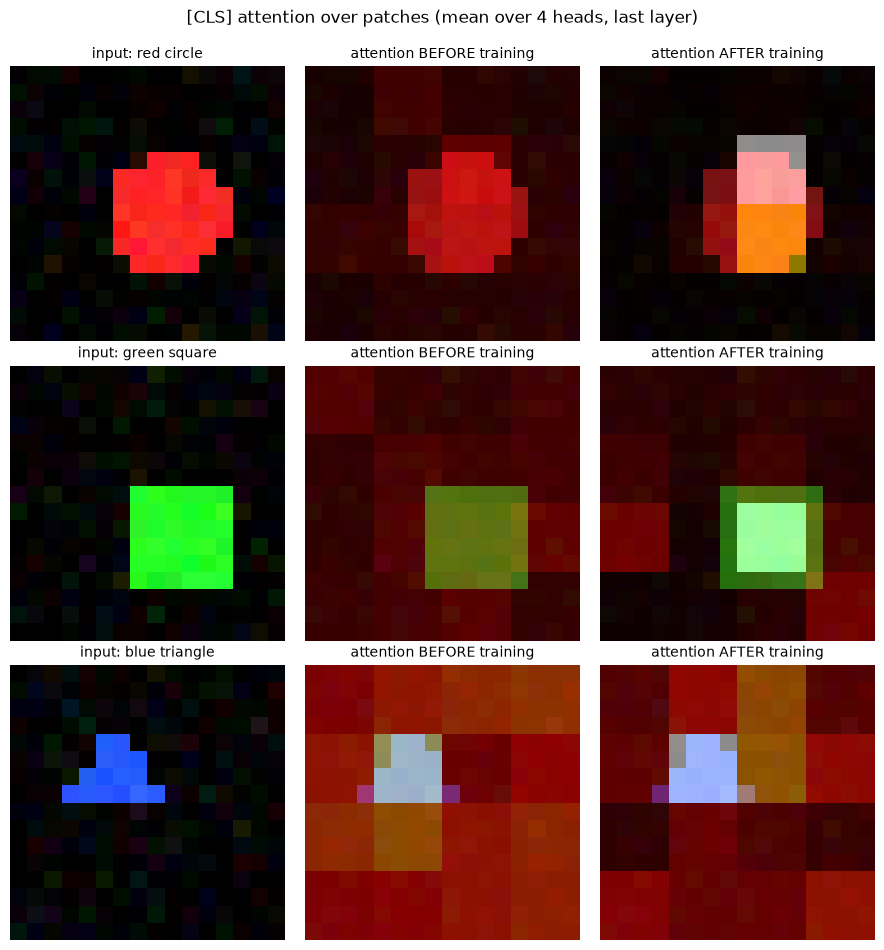

attention focus (mean max weight, uniform=1/16=0.062): before=0.100  after=0.325
corr(CLS attention, shape-in-patch):                   before=0.522  after=0.789
-> the model learned WHERE to look, with zero localization supervision


In [9]:
def cls_attention(p, imgs):
    """Mean-over-heads attention of [CLS] to the 16 patches, last layer; (N,16)"""
    _, attns, _ = forward(p, imgs)
    # A形状(N,H,17,17): 第0行=[CLS]作为query;列1..16=对16个patch的注意力
    return attns[-1][:, :, 0, 1:].mean(1)

# 先算好全测试集的注意力与逐图"注意力-形状位置"相关系数(下方还会汇报均值)
att_te_full = cls_attention(params, Xte)
pb_full = patchify(Xte).sum(-1)          # (N,16): 每patch总亮度~形状像素量
corr_full = np.array([np.corrcoef(a, b)[0, 1] for a, b in zip(att_te_full, pb_full)])
lg_te, _, _ = forward(params, Xte)
pred_te = lg_te.argmax(1)

# 挑3张不同形状的展示图(circle/square/triangle各一张):要求分类正确、
# 且相关系数>=0.75(接近全集均值0.79)——展示的是"平均水平"的成功案例,
# 不是精挑的最好情形;诚实的整体数字在本cell最后打印
demo_idx = [int(np.where((yte == k) & (pred_te == k) & (corr_full >= 0.75))[0][0])
            for k in [0, 4, 8]]
demo_imgs = Xte[demo_idx]
att_before = cls_attention(params_untrained, demo_imgs)
att_after = cls_attention(params, demo_imgs)

fig, axes = plt.subplots(3, 3, figsize=(9, 9.5))
for row in range(3):
    img = demo_imgs[row]
    c, s = ALL_PAIRS[yte[demo_idx[row]]]
    for col, (att, ttl) in enumerate([(None, f'input: {c} {s}'),
                                      (att_before[row], 'attention BEFORE training'),
                                      (att_after[row], 'attention AFTER training')]):
        ax = axes[row, col]
        ax.imshow(img)
        if att is not None:
            # Kronecker积上采样:4x4注意力网格 -> 16x16像素热力图(每patch铺满4x4)
            up = np.kron(att.reshape(NP_SIDE, NP_SIDE), np.ones((P, P)))
            # 每行共用"训练后最大值"做vmax:同一张图的前/后可直接对比亮度
            ax.imshow(up, cmap='hot', alpha=0.55, vmin=0, vmax=att_after[row].max())
        ax.set_title(ttl, fontsize=10)
        ax.axis('off')
plt.suptitle('[CLS] attention over patches (mean over 4 heads, last layer)', y=0.995)
plt.tight_layout(); plt.show()

# 定量:注意力与"patch中形状像素量"(patch亮度)的相关系数
def att_shape_corr(att_batch, imgs):
    """Per-image correlation between CLS attention and shape mass per patch"""
    pb = patchify(imgs).sum(-1)   # (N,16): 每个patch的总亮度~形状像素多少
    return np.array([np.corrcoef(a, b)[0, 1] for a, b in zip(att_batch, pb)]).mean()

att_te_before = cls_attention(params_untrained, Xte)
att_te_after = cls_attention(params, Xte)
corr_before = att_shape_corr(att_te_before, Xte)
corr_after = att_shape_corr(att_te_after, Xte)
# 聚焦度:注意力最大权重的均值;完全均匀时=1/16=0.062
foc_before = att_te_before.max(1).mean()
foc_after = att_te_after.max(1).mean()
print(f'attention focus (mean max weight, uniform=1/16=0.062): before={foc_before:.3f}  after={foc_after:.3f}')
print(f'corr(CLS attention, shape-in-patch):                   before={corr_before:.3f}  after={corr_after:.3f}')
print('-> the model learned WHERE to look, with zero localization supervision')

## Position Embedding Structure(位置编码学到了什么)

#### 💻 代码解读

**做什么:** 检查 16 个 patch 位置编码两两之间的余弦相似度矩阵,看训练是否让位置编码携带空间结构(ViT 论文 Fig 10 的迷你版)。

**怎么做:**
- 位置编码各行 L2 归一化后做 `@`,得到 16×16 余弦相似度矩阵;patch 按行优先编号(0~3 第一行,12~15 最后一行)。
- 按空间角色分组统计:中心 4 个 patch(编号 5/6/9/10,形状主要出现的区域)vs 边缘 12 个 patch。
- 结果:中心-中心相似度(0.100)约为中心-边缘(0.020)的 5 倍——位置编码把"内容区"和"背景区"区分开了,这是与任务相关的粗粒度空间结构;但绝对幅度很小,结构**微弱**。
- ViT 论文 Fig 10 那种精细的 2D 网格结构(每个位置与同行/同列邻居更相似)**没有出现**:我们的任务对精确位置几乎不敏感(下一节会证明),而且数据只有 1800 张——再次呼应"位置结构是数据和任务需求喂出来的,不是架构自带的"。

cosine similarity: center-center=0.100  center-border=0.020  border-border=0.044


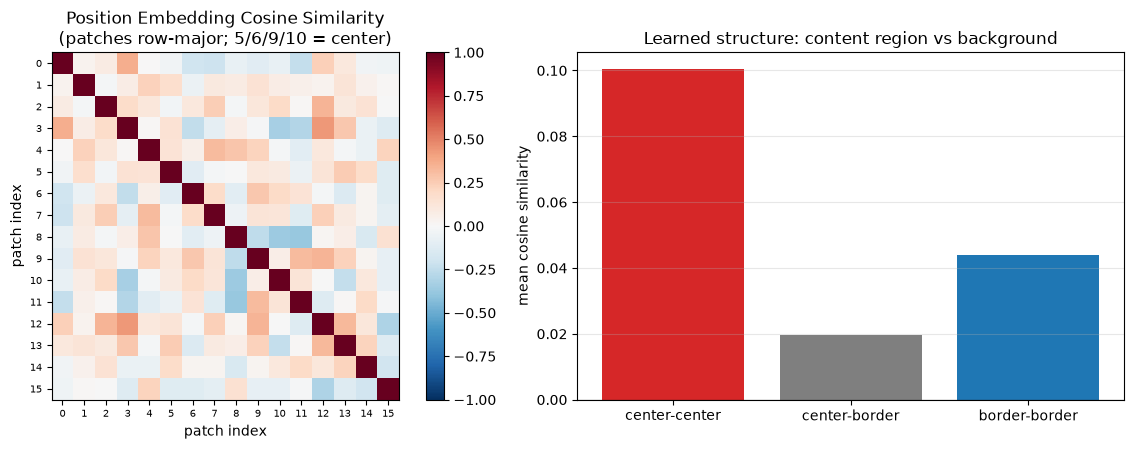

In [10]:
pos_patch = params['pos'][1:]          # 去掉[CLS],只看16个patch的位置编码
pn = pos_patch / np.linalg.norm(pos_patch, axis=1, keepdims=True)
pos_sim = pn @ pn.T                     # (16,16)两两余弦相似度

# 按空间角色分组:中心4个patch(形状主要出现区) vs 边缘12个
center = np.zeros(16, bool)
center[[5, 6, 9, 10]] = True
off_diag = ~np.eye(16, dtype=bool)
cc = pos_sim[np.ix_(center, center)][~np.eye(4, dtype=bool)].mean()
cb = pos_sim[np.ix_(center, ~center)].mean()
bb = pos_sim[np.ix_(~center, ~center)][~np.eye(12, dtype=bool)].mean()
print(f'cosine similarity: center-center={cc:.3f}  center-border={cb:.3f}  border-border={bb:.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
im = ax1.imshow(pos_sim, cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xticks(range(16)); ax1.set_yticks(range(16))
ax1.set_xticklabels(range(16), fontsize=7); ax1.set_yticklabels(range(16), fontsize=7)
ax1.set_title('Position Embedding Cosine Similarity\n(patches row-major; 5/6/9/10 = center)')
ax1.set_xlabel('patch index'); ax1.set_ylabel('patch index')
plt.colorbar(im, ax=ax1, fraction=0.046)
ax2.bar(['center-center', 'center-border', 'border-border'], [cc, cb, bb],
        color=['#d62728', '#7f7f7f', '#1f77b4'])
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('mean cosine similarity')
ax2.set_title('Learned structure: content region vs background')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## Does This ViT Even Need Positions?(消融:这个 ViT 到底需不需要位置)

#### 💻 代码解读

**做什么:** 两个推理时消融实验,直接量化位置信息的作用:(1) 把位置编码整体清零;(2) 保留位置编码但把 16 个 patch 随机打乱再输入。

**怎么做:**
- 自注意力对 token 顺序是**完全置换等变**的——如果没有位置编码,ViT 就是一个纯粹的"patch 集合处理器"(Paper 8 的 set-to-seq 思想)。位置编码是它感知空间布局的**唯一**通道。
- 清零位置编码:测出模型对"patch 内容袋"的依赖程度;打乱 patch:保留位置编码但破坏内容与位置的对应关系。
- 结果:两种破坏都只让准确率下降几个百分点——**这个任务近似置换不变**(颜色是逐像素属性;圆/方/三角的 patch 内容本身就带弧形边/直边/斜边的签名,不看排列也能大致分辨)。
- 这解释了上一节位置编码结构为何很弱,也呼应 ViT 论文的发现:1D/2D/相对位置编码的差异微乎其微。**判断一个视觉任务多依赖空间结构,做这个消融就知道。**

normal:            93.5%
pos emb zeroed:    91.8%
patches shuffled:  90.2%
-> this task is nearly permutation-invariant; positions help only a little


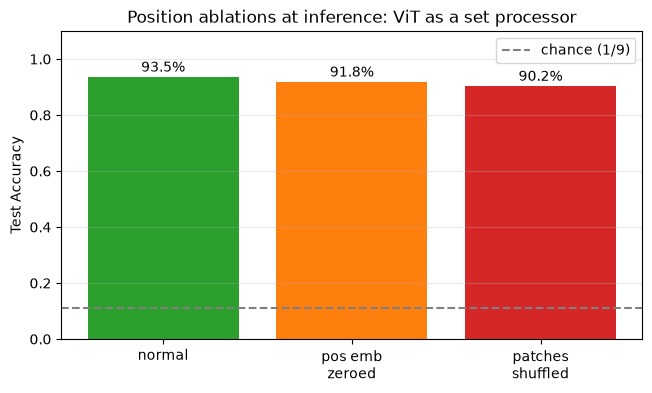

In [11]:
# 消融1: 推理时把位置编码清零(模型退化成纯"patch集合处理器")
p_nopos = {k: (np.zeros_like(v) if k == 'pos' else v) for k, v in params.items()}
lg_nopos, _, _ = forward(p_nopos, Xte)
acc_nopos = (lg_nopos.argmax(1) == yte).mean()

# 消融2: 保留位置编码,但把16个patch随机打乱(破坏内容-位置对应)
perm = np.random.default_rng(7).permutation(N_PATCH)
lg_shuf, _, _ = forward_tokens(params, patchify(Xte)[:, perm, :])
acc_shuf = (lg_shuf.argmax(1) == yte).mean()

print(f'normal:            {test_acc:.1%}')
print(f'pos emb zeroed:    {acc_nopos:.1%}')
print(f'patches shuffled:  {acc_shuf:.1%}')
print('-> this task is nearly permutation-invariant; positions help only a little')

plt.figure(figsize=(7.5, 4))
bars = plt.bar(['normal', 'pos emb\nzeroed', 'patches\nshuffled'],
               [test_acc, acc_nopos, acc_shuf], color=['#2ca02c', '#ff7f0e', '#d62728'])
for b, a in zip(bars, [test_acc, acc_nopos, acc_shuf]):
    plt.text(b.get_x() + b.get_width() / 2, a + 0.02, f'{a:.1%}', ha='center')
plt.axhline(1 / 9, color='gray', ls='--', label='chance (1/9)')
plt.ylabel('Test Accuracy'); plt.ylim(0, 1.1)
plt.title('Position ablations at inference: ViT as a set processor')
plt.legend(); plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Why ViT Needs Big Data(为什么 ViT 需要大数据:归纳偏置 vs 数据规模)

#### 💻 代码解读

**做什么:** 复现 ViT 论文最重要结论的微缩版:在 50 / 100 / 400 / 1600 个训练样本上,分别训练迷你 ViT(4.1 万参数,零先验)和多项逻辑回归(约 7 千参数,凸问题),对比测试准确率。每个数据量跑 3 个随机种子取均值,画出 min-max 区间带。

**怎么做:**
- 每个 (数据量, 种子) 组合:从训练池中无放回抽 n 张图;ViT 重新初始化、训练 600 步;逻辑回归(softmax 回归,输入为展平的 768 维原始像素)用同样的 Adam 训练 600 步——公平起见,两者步数、学习率、batch 完全相同。
- 同时打印 ViT 的**训练集**准确率:小数据时 ViT 训练集 100% 而测试很低 = 纯记忆,泛化 gap 巨大。
- 预期结果:小数据时简单模型反而更好(容量小 = 隐式正则);数据增大后 ViT 的容量优势兑现,大幅反超——两条曲线在几百样本处交叉。
- 这正是 ViT 论文 Fig 3/4 的机制:ViT 没有卷积的局部性/平移等变性先验,只能"用数据学出先验";数据不够时先验缺失就是纯劣势。原论文用 ImageNet(128 万)→ JFT-300M(3 亿)才让 ViT 反超 CNN,我们用 50→1600 就能看到同一条曲线的形状。

n=  50: ViT test=0.388 (train=1.000)  logistic regression test=0.450   (mean of 3 seeds)
n= 100: ViT test=0.424 (train=1.000)  logistic regression test=0.480   (mean of 3 seeds)
n= 400: ViT test=0.660 (train=1.000)  logistic regression test=0.598   (mean of 3 seeds)
n=1600: ViT test=0.911 (train=0.994)  logistic regression test=0.651   (mean of 3 seeds)


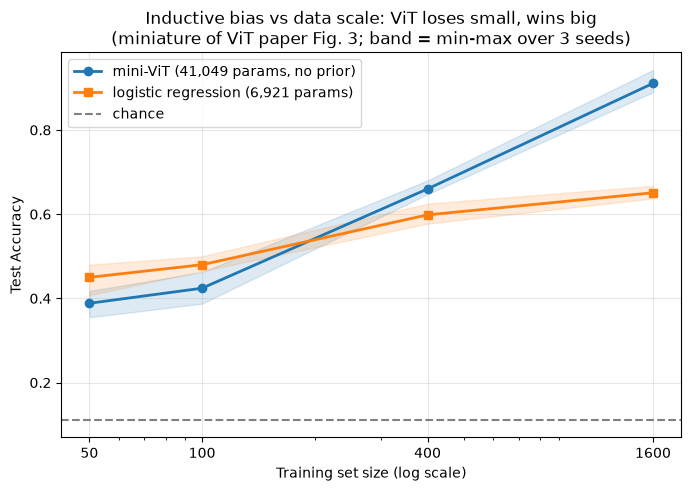

In [12]:
sizes = [50, 100, 400, 1600]
SEEDS = [0, 1, 2]
vit_mat = np.zeros((len(SEEDS), len(sizes)))     # ViT测试准确率
vit_tr_mat = np.zeros((len(SEEDS), len(sizes)))  # ViT训练集准确率(看记忆程度)
lin_mat = np.zeros((len(SEEDS), len(sizes)))     # 逻辑回归测试准确率
Xte_flat = Xte.reshape(len(Xte), -1)

for si, seed in enumerate(SEEDS):
    for ni, n in enumerate(sizes):
        rngd = np.random.default_rng(1000 * seed + n)  # 每个(种子,数据量)独立随机源
        # 无放回抽n张:不同种子抽到不同子集,衡量小样本结论的稳定性
        sub = rngd.choice(len(Xtr), n, replace=False)
        Xs, ys = Xtr[sub], ytr[sub]
        Xf = Xs.reshape(n, -1)
        # ---- mini-ViT: 重新初始化,训练600步 ----
        pv = init_params(rngd)
        mv = {k: np.zeros_like(x) for k, x in pv.items()}
        vv = {k: np.zeros_like(x) for k, x in pv.items()}
        for step in range(1, 601):
            idx = rngd.integers(0, n, min(B, n))
            _, _, g, _ = loss_and_grads(pv, Xs[idx], ys[idx])
            adam_update(pv, g, mv, vv, step, lr=1.5e-3)
        lgv, _, _ = forward(pv, Xte)
        vit_mat[si, ni] = (lgv.argmax(1) == yte).mean()
        lgt, _, _ = forward(pv, Xs)
        vit_tr_mat[si, ni] = (lgt.argmax(1) == ys).mean()
        # ---- 基线: 多项逻辑回归(原始像素768维->9类), 相同步数/学习率/batch ----
        plin = {'W': np.zeros((IMG * IMG * 3, N_CLASS)), 'b': np.zeros(N_CLASS)}
        ml = {k: np.zeros_like(x) for k, x in plin.items()}
        vl = {k: np.zeros_like(x) for k, x in plin.items()}
        for step in range(1, 601):
            idx = rngd.integers(0, n, min(B, n))
            pp = softmax(Xf[idx] @ plin['W'] + plin['b'])
            dd = pp.copy()
            dd[np.arange(len(idx)), ys[idx]] -= 1
            dd /= len(idx)
            adam_update(plin, {'W': Xf[idx].T @ dd, 'b': dd.sum(0)}, ml, vl, step, lr=1.5e-3)
        lin_mat[si, ni] = ((Xte_flat @ plin['W'] + plin['b']).argmax(1) == yte).mean()

vit_mean, lin_mean = vit_mat.mean(0), lin_mat.mean(0)
for ni, n in enumerate(sizes):
    print(f'n={n:4d}: ViT test={vit_mean[ni]:.3f} (train={vit_tr_mat.mean(0)[ni]:.3f})  '
          f'logistic regression test={lin_mean[ni]:.3f}   (mean of {len(SEEDS)} seeds)')

plt.figure(figsize=(8, 5))
plt.plot(sizes, vit_mean, 'o-', lw=2, color='#1f77b4',
         label=f'mini-ViT ({n_params:,} params, no prior)')
# fill_between画出3个种子的min-max区间带,展示结论的稳定性
plt.fill_between(sizes, vit_mat.min(0), vit_mat.max(0), color='#1f77b4', alpha=0.15)
plt.plot(sizes, lin_mean, 's-', lw=2, color='#ff7f0e',
         label='logistic regression (6,921 params)')
plt.fill_between(sizes, lin_mat.min(0), lin_mat.max(0), color='#ff7f0e', alpha=0.15)
plt.axhline(1 / 9, color='gray', ls='--', label='chance')
plt.xscale('log')
plt.xticks(sizes, [str(s) for s in sizes])
plt.xlabel('Training set size (log scale)'); plt.ylabel('Test Accuracy')
plt.title('Inductive bias vs data scale: ViT loses small, wins big\n(miniature of ViT paper Fig. 3; band = min-max over 3 seeds)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## Key Takeaways(要点总结)

1. **Images as token sequences**: patchify = one reshape+transpose; a standard Transformer encoder then classifies colored shapes at 93.5% with zero convolutions
2. **Backprop through attention is mechanical**: softmax rows (dS = A⊙(dA−Σ(dA⊙A))), residuals (add both branch gradients), RMSNorm (remove the radial component) — all verified against numerical gradients to < 1e-4
3. **[CLS] attention is a free saliency map**: attention sharpens from near-uniform (max weight 0.10) to focused on the object (0.33, correlation 0.79 with shape location) with no localization labels
4. **Position embeddings learn what the task needs**: here only a weak content-region structure emerges (center-center 0.100 vs center-border 0.020), and ablating positions costs under 2 points — the task is nearly permutation-invariant
5. **No inductive bias means data hunger**: the 41k-param ViT loses to 7k-param logistic regression at n=50-100 (42.4% vs 48.0% at n=100) but wins by 26 points at n=1600 (91.1% vs 65.1%) — the ViT paper's central finding in miniature

1. **图像即 token 序列**:切块只需一次 reshape+transpose;标准 Transformer 编码器零卷积做到 93.5% 分类准确率
2. **注意力的反向传播是纯机械推导**:softmax 行(dS = A⊙(dA−Σ(dA⊙A)))、残差(两支路梯度相加)、RMSNorm(扣除径向分量)——数值梯度校验误差 < 1e-4
3. **[CLS] 注意力是免费的显著性图**:注意力从近乎均匀(最大权重 0.10)变为聚焦在物体上(0.33,与形状位置相关系数 0.79),全程没有定位标签
4. **位置编码只学任务需要的东西**:这里只浮现出微弱的"内容区/背景区"结构(中心-中心 0.100 vs 中心-边缘 0.020),消融位置编码只掉不到 2 个点——本任务近似置换不变
5. **没有归纳偏置就要用数据补**:4.1 万参数的 ViT 在 n=50~100 时输给 7 千参数的逻辑回归(n=100 时 42.4% vs 48.0%),n=1600 时反超 26 个百分点(91.1% vs 65.1%)——ViT 论文核心结论的微缩版

**与本仓库其他论文的联系:** 注意力机制与编码器结构来自 Paper 13(Attention Is All You Need,本篇补上了它缺的反向传播);pre-norm 残差的"干净梯度通路"来自 Papers 10/15(ResNet 及其恒等映射分析);"把输入当集合处理"呼应 Paper 8(Seq2Seq for Sets);"模型容量 vs 数据规模"的权衡正是 Paper 22(Scaling Laws)的主题;而 ViT 本身就是 Bonus 31(CLIP)图像塔的真实架构——两篇 Bonus 合起来,就是现代多模态模型(LLaVA、GPT-4V)的完整视觉底座。